# 01 — Análise Exploratória de Dados (EDA)

**Projeto:** Predição de Diabetes com ML  
**Artigo base:** Khanam & Foo (2021) — DOI: 10.1016/j.icte.2021.02.004  
**Objetivo:** Investigar a distribuição dos atributos, relações de correlação, desbalanceamento de classes e presença de valores zero biologicamente impossíveis no dataset *Pima Indians Diabetes*.

In [1]:
# Instalar dependências (necessário no Google Colab)
import subprocess
subprocess.run(["pip", "install", "-r", "../requirements.txt", "-q"], check=True)
print("✓ Dependências instaladas")

✓ Dependências instaladas


In [2]:
# ── Configuração de caminhos ─────────────────────────────
import sys
from pathlib import Path
import os

IS_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    ROOT = Path('/content/diabetes-ml-prediction')
else:
    ROOT = Path('..').resolve()

sys.path.append(str(ROOT))

# ── Imports do projeto ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import *
from src.data_loader import load_dataset, summarize_dataset

In [3]:
# ── Reprodutibilidade e Estilo ───────────────────────────
import random
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"✓ Seeds fixadas: {SEED}")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")
print("✓ Estilo configurado")

✓ Seeds fixadas: 42
✓ Estilo configurado


In [4]:
# ── Carregamento do dataset ──────────────────────────────
df = load_dataset(ROOT / "data" / "diabetes.csv")
summarize_dataset(df)

✓ Dataset carregado: 768 registros
→ Resumo do Dataset:
  - Dimensões: 768 linhas × 9 colunas

→ Tipos de dados por coluna:
  - Pregnancies: int64
  - Glucose: int64
  - BloodPressure: int64
  - SkinThickness: int64
  - Insulin: int64
  - BMI: float64
  - DiabetesPedigreeFunction: float64
  - Age: int64
  - Outcome: int64

→ Estatísticas descritivas:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age     Outcome
count   768.000000  768.000000     768.000000     768.000000  768.000000  768.000000                768.000000  768.000000  768.000000
mean      3.845052  120.894531      69.105469      20.536458   79.799479   31.992578                  0.471876   33.240885    0.348958
std       3.369578   31.972618      19.355807      15.952218  115.244002    7.884160                  0.331329   11.760232    0.476951
min       0.000000    0.000000       0.000000       0.000000    0.000000    0.000000                  0.078

### 1. Qual a distribuição de cada atributo? (histogramas)

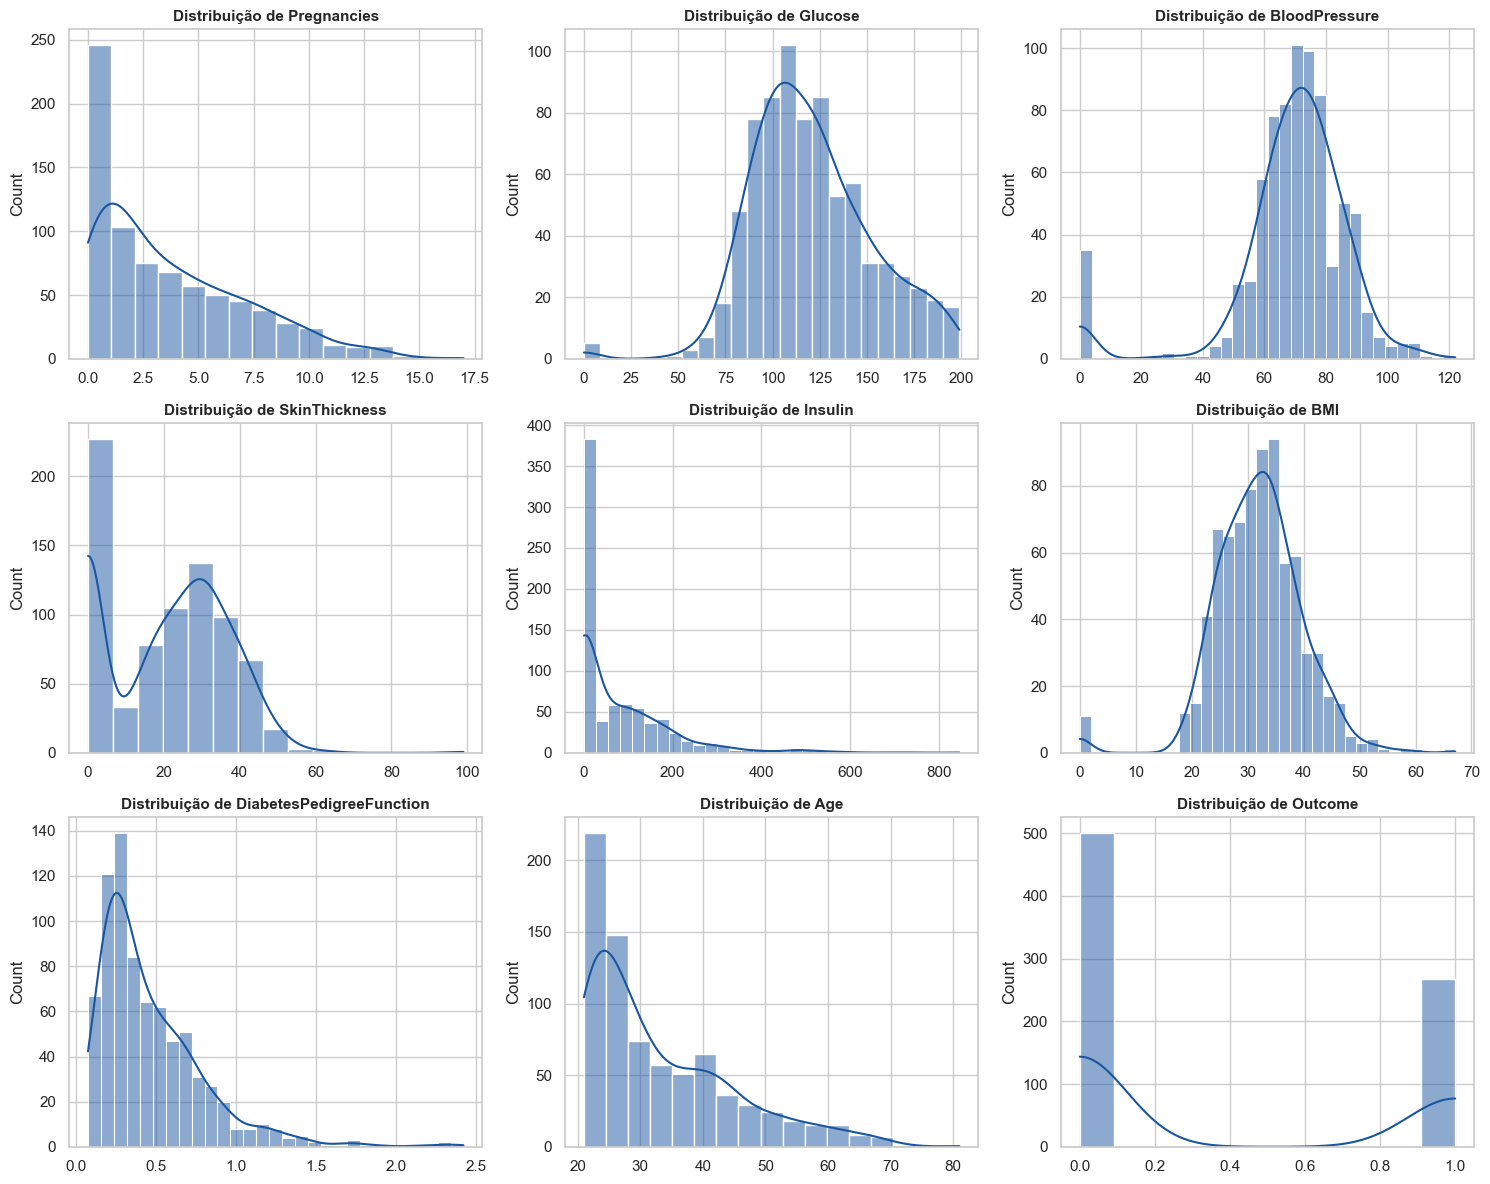

In [5]:
# ── Plot de histogramas de distribuição ──────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[idx], kde=True, color='#1A56A0')
    axes[idx].set_title(f'Distribuição de {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()

### 2. Existe correlação forte entre atributos? (heatmap de Pearson)

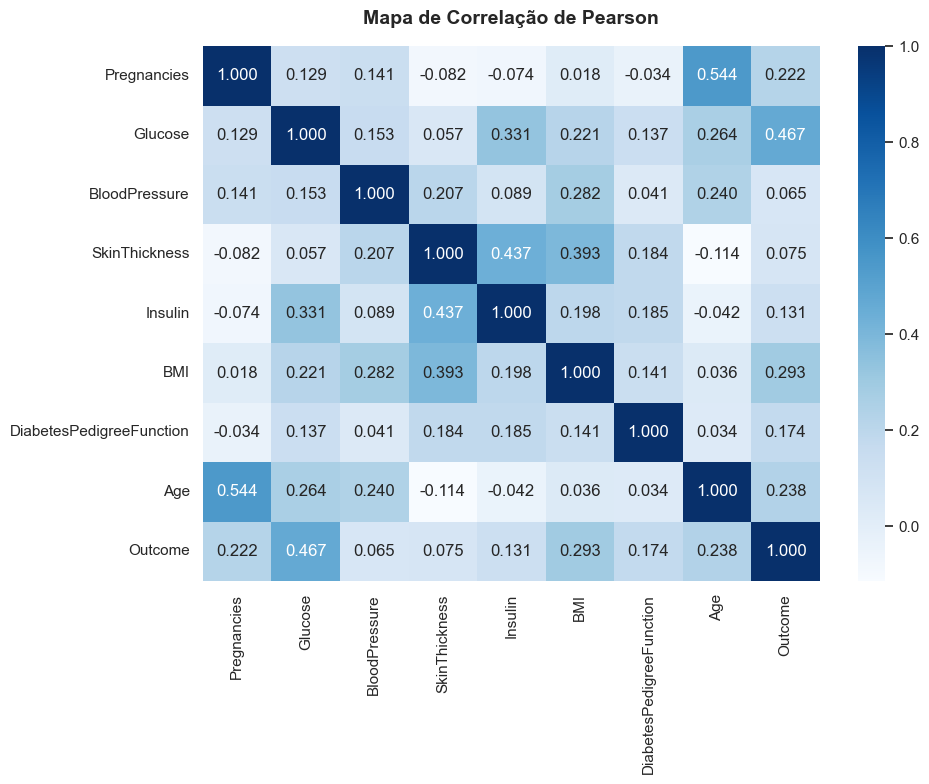

In [6]:
# ── Plot de correlação ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap='Blues', ax=ax, cbar=True)
ax.set_title('Mapa de Correlação de Pearson', fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

### 3. As classes estão balanceadas? (countplot)

C:\Users\Neri\AppData\Local\Temp\ipykernel_8064\94105546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette=['#1A56A0', '#E65100'], ax=ax)


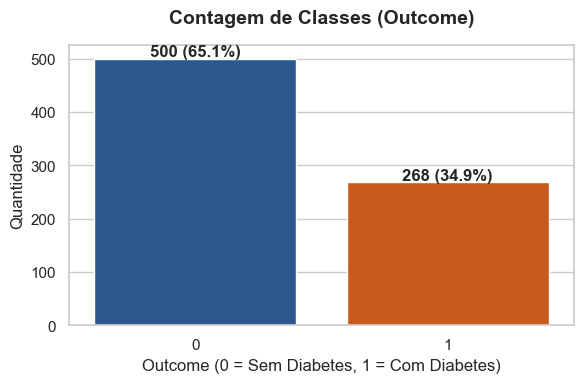

In [7]:
# ── Plot de contagem de classes ─────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette=['#1A56A0', '#E65100'], ax=ax)
ax.set_title('Contagem de Classes (Outcome)', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Outcome (0 = Sem Diabetes, 1 = Com Diabetes)')
ax.set_ylabel('Quantidade')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

### 4. Quais atributos diferem entre diabéticos e não-diabéticos? (boxplots por classe)

C:\Users\Neri\AppData\Local\Temp\ipykernel_8064\797522469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#1A56A0', '#E65100'], ax=axes[idx])
C:\Users\Neri\AppData\Local\Temp\ipykernel_8064\797522469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#1A56A0', '#E65100'], ax=axes[idx])


C:\Users\Neri\AppData\Local\Temp\ipykernel_8064\797522469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#1A56A0', '#E65100'], ax=axes[idx])
C:\Users\Neri\AppData\Local\Temp\ipykernel_8064\797522469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#1A56A0', '#E65100'], ax=axes[idx])
C:\Users\Neri\AppData\Local\Temp\ipykernel_8064\797522469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette=['#1A56A0', '#E65100'], ax=axe

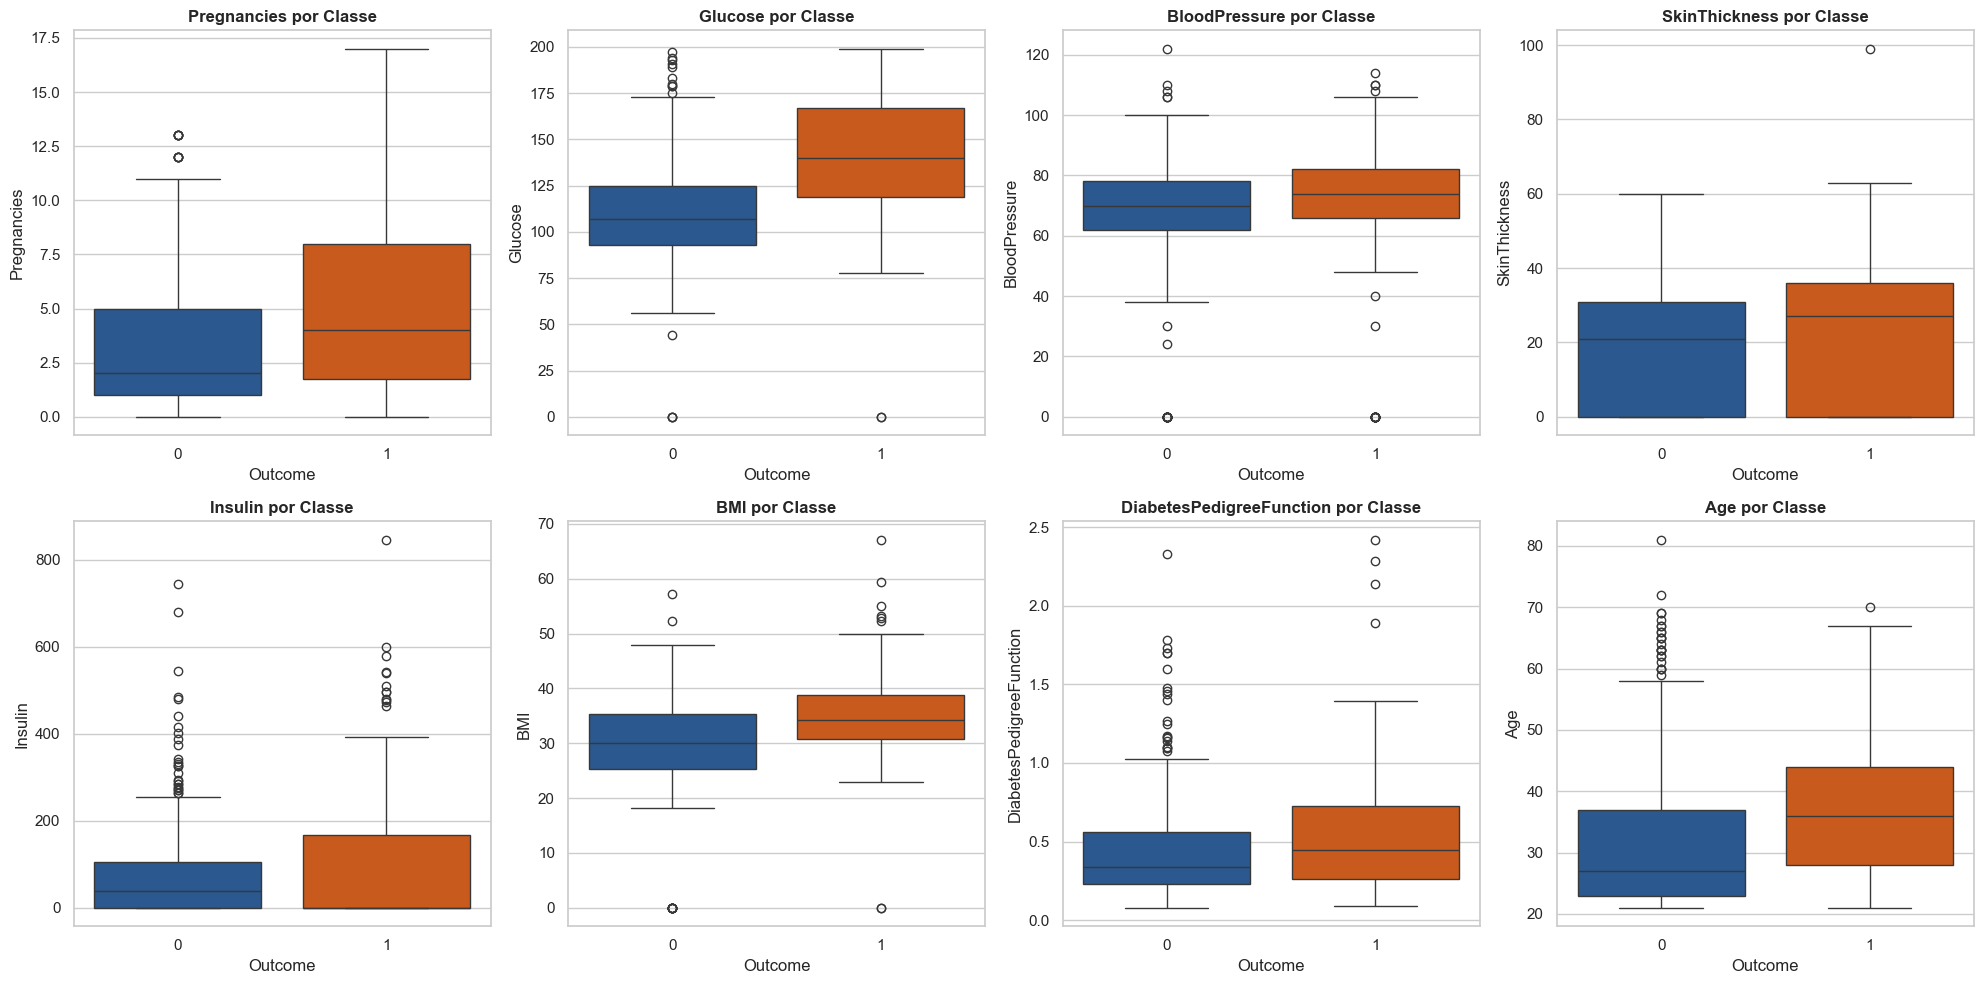

In [8]:
# ── Plot de boxplots ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
features = [col for col in df.columns if col != 'Outcome']

for idx, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, palette=['#1A56A0', '#E65100'], ax=axes[idx])
    axes[idx].set_title(f'{col} por Classe', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Outcome')

plt.tight_layout()
plt.show()

### 5. Quais colunas têm zeros suspeitos e quantos? (tabela)

In [9]:
# ── Tabela de zeros suspeitos ────────────────────────────
zero_data = []
for col in df.columns:
    zeros_count = (df[col] == 0).sum()
    percentage = (zeros_count / len(df)) * 100
    is_suspect = "Sim" if col in ZERO_COLS else "Não (Válido)"
    zero_data.append({
        "Coluna": col,
        "Quantidade de Zeros": zeros_count,
        "Percentual": f"{percentage:.2f}%",
        "Suspeito": is_suspect
    })
df_zeros = pd.DataFrame(zero_data)
print(df_zeros.to_string(index=False))

                  Coluna  Quantidade de Zeros Percentual     Suspeito
             Pregnancies                  111     14.45% Não (Válido)
                 Glucose                    5      0.65%          Sim
           BloodPressure                   35      4.56%          Sim
           SkinThickness                  227     29.56%          Sim
                 Insulin                  374     48.70%          Sim
                     BMI                   11      1.43%          Sim
DiabetesPedigreeFunction                    0      0.00% Não (Válido)
                     Age                    0      0.00% Não (Válido)
                 Outcome                  500     65.10% Não (Válido)


### 6. Após tratamento, a distribuição mudou? (antes/depois do tratamento de zeros)

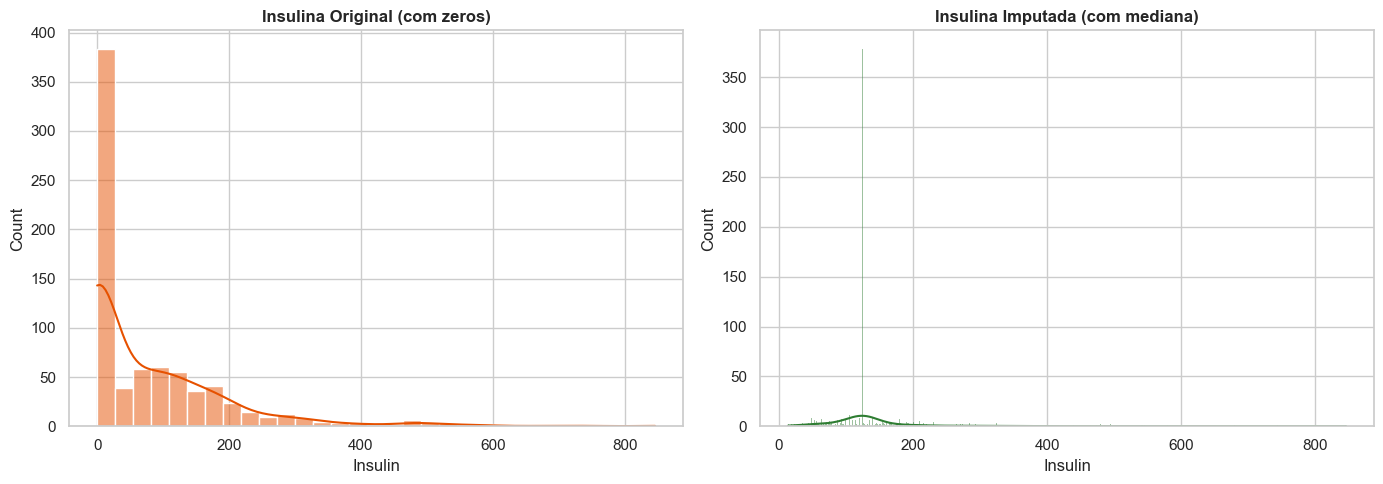

In [10]:
# ── Comparação antes/depois do tratamento ────────────────
from src.preprocessor import replace_zeros_with_nan, impute_with_median

df_nan = replace_zeros_with_nan(df, ZERO_COLS)
df_imputed = impute_with_median(df_nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Insulin'], ax=ax1, kde=True, color='#E65100')
ax1.set_title('Insulina Original (com zeros)', fontsize=12, fontweight='bold')

sns.histplot(df_imputed['Insulin'], ax=ax2, kde=True, color='#2E7D32')
ax2.set_title('Insulina Imputada (com mediana)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Resumo dos Resultados e Próximos Passos
- Identificou-se que o dataset está desbalanceado (34.9% positivos e 65.1% negativos).
- Glucose, BloodPressure, SkinThickness, Insulin e BMI contêm quantidades significativas de zeros suspeitos (ex: Insulin tem 374 zeros, correspondendo a 48.70% do dataset).
- Próximo passo: Executar o pipeline de pré-processamento completo em `02_preprocessamento.ipynb`.